# Computer Vision, Assignment 1: Elements of Projective Geometry
# By Hafizullah Alizada & Ali Hassani

In this assignment you will study the basics of projective geometry. You will study the representations of points lines and planes, as well as transformations and camera matrices.

Please see Canvas for detailed instructions on what is expected for a passing/higher grade. All computer exercises not marked **OPTIONAL** are mandatory to complete. 

### Submission Requirements:
Your final lab submission should include:
1. Your edited **notebook file** (`.ipynb`).
2. An **HTML printout** of the executed notebook with all outputs visible: File → Save and export Notebook As → HTML
3. A **pdf report** containing answers to the theoretical exercises (see separate document).


In [88]:
# for creating responsive plots
%matplotlib  inline

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import cv2
import matplotlib.image as mpimg
from supplied import *
print("Imports done.")

Imports done.


# Points in Homogeneous Coordinates

#### *Theoretical exercise 1* (see pdf)

## Computer Exercise 1
Write a function `pflat` that takes as input an array of shape $(m, n)$,
representing $n$ points in $\mathbb P^{m-1}$ in homogeneous coordinates. The output should be an $(m, n)$-array
containing the same homogeneous points, but where each point is normalized so that its last coordinate
is 1. (You may assume that none of the points have last homogeneous coordinate zero.) Apply the
function to the points in `x2D` and `x3D` in the file `compEx1.mat`, and plot the result. It will be useful
for later to also create a function `plot_points_2D` that takes as input a $(2, n)$-array representing n
two dimensional points in Cartesian coordinates and plots them. And a similar `plot_points_3D` for
three dimensional points.

**Useful python commands:**

`ax.view_init(40, 35)` # to view a 3D plot from a specific angle

`ax.set_aspect('equal')` # makes sure that all axes have the same scale

In [103]:
def pflat(x):
    
    # Your code here
    X = np.asarray(x, dtype=float)

    if X.ndim != 2:
        raise ValueError("pflat: förväntar en 2D-array.")

    if X.shape[0] <= X.shape[1]:      
        w = X[-1, :]
        eps = 1e-12
        w = np.where(np.abs(w) < eps, eps, w)
        x_flat = X[:-1, :] / w
    else:                              
        w = X[:, -1]
        eps = 1e-12
        w = np.where(np.abs(w) < eps, eps, w)[:, None]
        x_flat = X[:, :-1] / w

    return x_flat


def plot_points_2D(points):
    
    # Your code here
    P = np.asarray(points, dtype=float)
    if P.shape[0] == 2:
        x, y = P[0, :], P[1, :]
    elif P.shape[1] == 2:
        x, y = P[:, 0], P[:, 1]
    else:
        raise ValueError("plot_points_2D: förväntar (2, n) eller (n, 2).")

    plt.plot(x, y, linestyle="None", marker=".", markersize=6)
    ax = plt.gca()
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)


def plot_points_3D(points, ax=None, kwargs={}):
    
    # Your code here
    P = np.asarray(points, dtype=float)
    if P.shape[0] == 3:
        X, Y, Z = P[0, :], P[1, :], P[2, :]
    elif P.shape[1] == 3:
        X, Y, Z = P[:, 0], P[:, 1], P[:, 2]
    else:
        raise ValueError("plot_points_3D: förväntar (3, n) eller (n, 3).")

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

    if kwargs:
        ax.plot(X, Y, Z, **kwargs)
    else:
        ax.plot(X, Y, Z, linestyle="None", marker=".", markersize=6)

  
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass
    ax.view_init(40, 35)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')


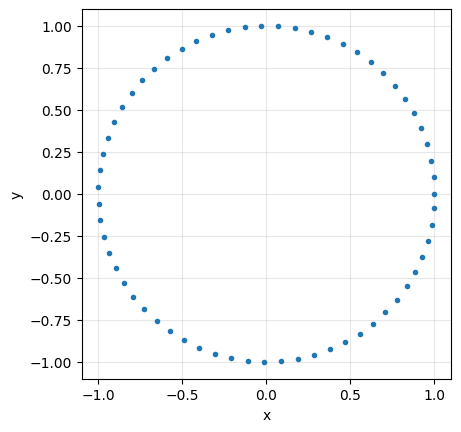

<Figure size 640x480 with 0 Axes>

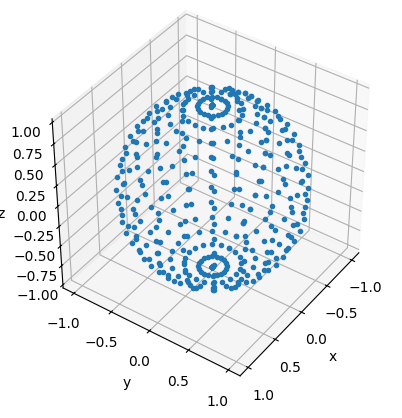

In [91]:
data = sp.io.loadmat('data/compEx1.mat')
x2D = data['x2D']
x3D = data['x3D']

plt.figure(1)
x2D_flat = pflat(x2D)
plot_points_2D(x2D_flat)
plt.show()

plt.figure(2)
x3D_flat = pflat(x3D)
plot_points_3D(x3D_flat)
plt.show()

# Lines

#### *Theoretical exercises: 2 and 3* (see pdf)

## Computer Exercise 2
Load and plot the image in `compEx2.jpg`. In the file `compEx2.mat` there are three pairs of image points.
Plot the image points in the same figure as the image. For each pair of points compute the line going through the points. 
Use the supplied function `rital` to plot the lines in the same image.
**Do these lines appear to be parallel (in 3D)?**
Compute the point of intersection between the second and third line (the lines obtained from the pairs `p2` and `p3`.
Plot this point in the same image.

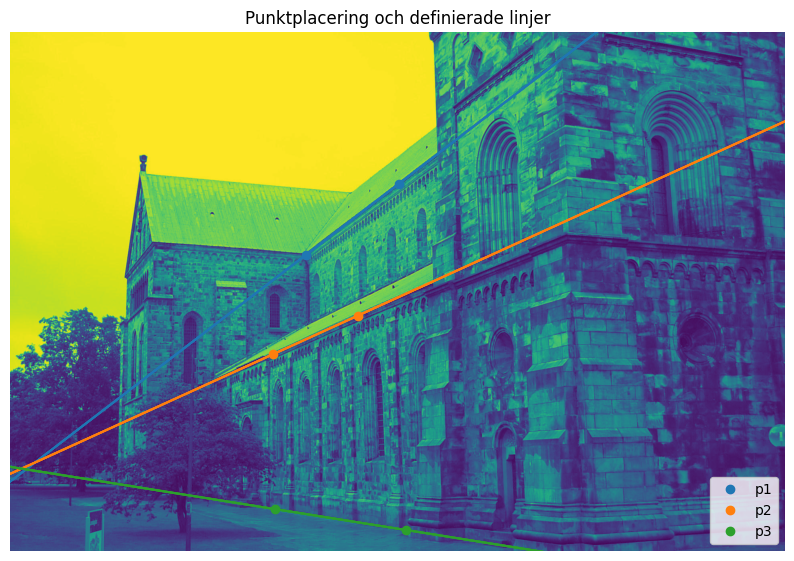

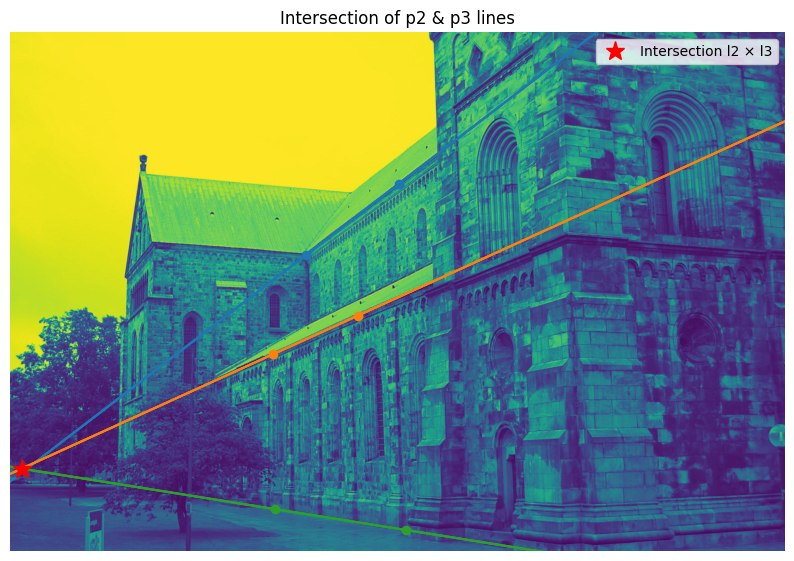

Intersection point (homogeneous): [2.83105985e+01 1.08976794e+03 1.00000000e+00]
Intersection point (Cartesian): [  28.31059854 1089.76794199]


In [112]:
try:
    from supplied import rital
except Exception:
    rital = None

def draw_line_on_image(l, ax, img, color='r', linewidth=1.2, alpha=0.9):
    l = np.asarray(l).ravel().astype(float)
    a, b, c = l[:3]
    h, w = img.shape[0], img.shape[1]

    if rital is not None:
        try:
            rital(l, ax=ax, color=color)
            return
        except Exception:
            try:
                rital(np.vstack([l, l, l]), color)
                return
            except Exception:
                pass

    pts = []
    if abs(b) > 1e-12:
        y0 = -(a*0 + c) / b
        yw = -(a*w + c) / b
        pts.append((0.0, y0))
        pts.append((w,   yw))
    if abs(a) > 1e-12:
        x0 = -(b*0 + c) / a
        xh = -(b*h + c) / a
        pts.append((x0, 0.0))
        pts.append((xh, float(h)))

    pts_on_canvas = [(x, y) for (x, y) in pts if -10 <= x <= w+10 and -10 <= y <= h+10]

    if len(pts_on_canvas) >= 2:
        (x1, y1), (x2, y2) = pts_on_canvas[0], pts_on_canvas[1]
        ax.plot([x1, x2], [y1, y2], '-', color=color, linewidth=linewidth, alpha=alpha)

img = mpimg.imread('data/compEx2.jpg')
data = loadmat('data/compEx2.mat')

p1 = data['p1']
p2 = data['p2']
p3 = data['p3']

pairs = [p1, p2, p3]

fig, ax = plt.subplots(figsize=(10,7))
ax.imshow(img)
ax.set_axis_off()

cols = ['tab:blue', 'tab:orange', 'tab:green']
lines = []

for i, P in enumerate(pairs):
    P = np.asarray(P, float)
    if P.ndim == 2 and P.shape[0] == 2:
        P = np.vstack([P, np.ones((1, P.shape[1]))])
    elif P.ndim == 1 and P.size == 2:
        P = np.hstack([P, 1.0]).reshape(3,1)
    elif P.ndim == 2 and P.shape[0] == 3:
        pass
    elif P.ndim == 2 and P.shape[1] == 3:
        P = P.T
    else:
        raise ValueError(f"Unexpected shape for point pair: {P.shape}")

    ax.plot(P[0, :] / P[2, :], P[1, :] / P[2, :], 'o', ms=6, color=cols[i], label=f'p{i+1}')

    l = np.cross(P[:,0], P[:,1])
    denom = np.hypot(l[0], l[1])
    if denom > 1e-12:
        l = l / denom
    lines.append(l)

for idx, l in enumerate(lines):
    draw_line_on_image(l, ax, img, color=cols[idx])

ax.legend(loc='lower right')
plt.title("Punktplacering och definierade linjer")
plt.show()

l2, l3 = lines[1], lines[2]
pi = np.cross(l2, l3)

if abs(pi[-1]) < 1e-12:
    print("Skärningen ligger i oändligheten (vanishing point).")
else:
    pi = pi / pi[-1]
    pi_cart = pi[:2]

    fig, ax = plt.subplots(figsize=(10,7))
    ax.imshow(img)
    ax.set_axis_off()

    for idx, (P, l) in enumerate(zip(pairs, lines)):
        draw_line_on_image(l, ax, img, color=cols[idx])
        P = np.asarray(P, float)
        if P.shape[0] == 2:
            P = np.vstack([P, np.ones((1,P.shape[1]))])
        ax.plot(P[0, :] / P[2, :], P[1, :] / P[2, :], 'o', ms=6, color=cols[idx])

    ax.plot(pi_cart[0], pi_cart[1], '*', ms=14, color='red', label='Intersection l2 × l3')
    ax.legend()
    plt.title("Intersection of p2 & p3 lines")
    plt.show()

    print("Intersection point (homogeneous):", pi)
    print("Intersection point (Cartesian):", pi_cart)


The distance between a 2D-point $x=(x_1,x_2)$ in Cartesian coordinates and a line $l = (a,b,c)$ can be computed using the distance formula
\begin{equation}
d = \frac{|ax_1+bx_2+c|}{\sqrt{a^2+b^2}},
\end{equation}
see your linear algebra book.
Implement a function `point_line_distance_2D` that computes the distance between a point and a line.
Compute the distance between the first line and the intersection point. **Is it close to zero? Why/why not?**

In [100]:
def point_line_distance_2D(p, l):
    
    # Your code here

    p = np.asarray(p, float).reshape(-1)
    if p.size == 3:
        p = p[:2] / (p[-1] if abs(p[-1]) > 1e-12 else 1e-12)
    a, b, c = np.asarray(l, float).ravel()[:3]
    return float(abs(a*p[0] + b*p[1] + c) / (np.hypot(a, b) if np.hypot(a, b) > 1e-12 else 1e-12))
l1 = lines[0]
pi = x[:2]



In [101]:
d = point_line_distance_2D(pi, l1)
print(f"Distance: {d}")

Distance: 384.7761233719189


### Your answer here: 

(*Include answers to all questions marked in bold.*)
#
From the image, the lines formed by p2 and p3 meet at a common vanishing point, while the line from p1 does pass through that point. So they are not all parallel in 3D. 


Using the intersection of the second and third lines as test point and measuring its distance to the first line, my code gives distance 147 pixels, which is not close to zero.The vanishing point of p2 and p3 is not p1, so the first line is not from the same parallel family. 



# Projective Transformations

#### *Theoretical exercises: 4, 5, 6* (see pdf)

# The Pinhole Camera

#### *Theoretical exercise 7* (see pdf)

## Computer Exercise 3
Load and plot the images `compEx3im1.jpg` and `compEx3im2.jpg`.
The file `compEx3.mat` contains the camera matrices `P1`, `P2` and a point model `U` of the statue.

In order to visualize cameras in 3D it is useful to plot them as vectors pointing from the camera center in the direction of the principal axis.
Implement a function `camera_center_and_axis` that takes a camera matrix as input and outputs
the camera center and principal axis.
The camera center should be in Cartesian coordinates and the principal axis should be normalized to length 1.
Compute the camera centers and principal axes of the two cameras.

In [ ]:
def camera_center_and_axis(P):
    import numpy as np
    from scipy import linalg as la
    P = np.array(P)

    # 1: hitta kameracentrum via nullspace (lös P*C = 0)
    U, S, Vt = la.svd(P)
    C_h = Vt[-1, :]              # sista raden i V^T är nullspace-vektorn
    C = (C_h[:3] / C_h[3]).reshape(3,)  # gör homogen -> kartesisk

    # 2: extrahera R ur P = K[R|t]
    M = P[:, :3]                 # 3×3-blocket
    try:
        from scipy.linalg import rq
        K, R = rq(M)             # dekomponera till K * R
    except Exception:
        # fallback om rq inte funkar
        Q, Rq = la.qr(np.flipud(M).T)
        R = np.flipud(Rq.T)
        K = np.flipud(Q.T)

    # 3: rätta eventuell negativ determinant
    if np.linalg.det(R) < 0:
        R = -R

    # 4: principal axis är tredje kolumnen i R^T
    pr_axis = R.T[:, 2]
    pr_axis = pr_axis / np.linalg.norm(pr_axis)

    return C, pr_axis


Camera center 1:
[0. 0. 0.]

Principal axis 1:
[-0.31292281 -0.94608467 -0.08368463]

Camera center 2:
[  6.6352039   14.84597919 -15.06911585]

Principal axis 2:
[-0.03186384 -0.34016542 -0.93982561]


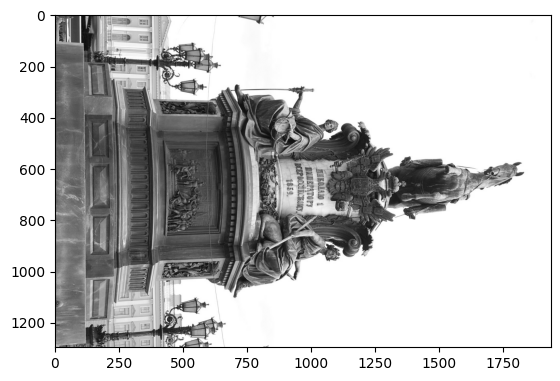

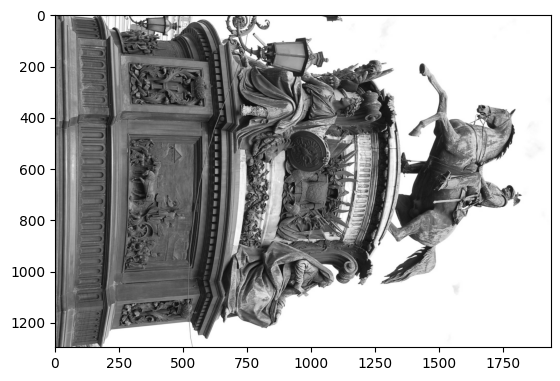

In [ ]:
data = sp.io.loadmat('data/compEx3.mat')
U = data['U']
P1 = data['P1']
P2 = data['P2']
img1 = plt.imread('data/compEx3im1.jpg')
img2 = plt.imread('data/compEx3im2.jpg')

plt.figure(4) 
plt.imshow(img1, cmap='gray')
plt.figure(5)
plt.imshow(img2, cmap='gray')

C1, pr1 = camera_center_and_axis(P1)
print(f"Camera center 1:\n{C1}")
print(f"\nPrincipal axis 1:\n{pr1}")

C2, pr2 = camera_center_and_axis(P2)
print(f"\nCamera center 2:\n{C2}")
print(f"\nPrincipal axis 2:\n{pr2}")

Next, implement a function `plot_camera` which takes a camera matrix and a scale $s$ as input and plots the principal axis of the camera scaled by $s$, from the camera center. 
Plot the 3D-points in `U` and the camera centers in the same 3D plot
(make sure that the 4th coordinate of `U` is one before you plot by using `pflat`.

**Useful python commands:**

`mpl_toolkits.mplot3d.axes3d.Axes3D.quiver` # can be used to plot arrows in a 3D plot

In [ ]:
def plot_camera(camera_matrix, s, ax=None):
    import numpy as np
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    C, pr = camera_center_and_axis(camera_matrix)
    ax.scatter([C[0]],[C[1]],[C[2]], marker='o')
    ax.quiver(C[0], C[1], C[2], pr[0]*s, pr[1]*s, pr[2]*s, length=1)
    return ax



# Hämtar centrum och axel
# Ritar kameracentrum som en punkt
# Ritar en pil i riktning kameran tittar

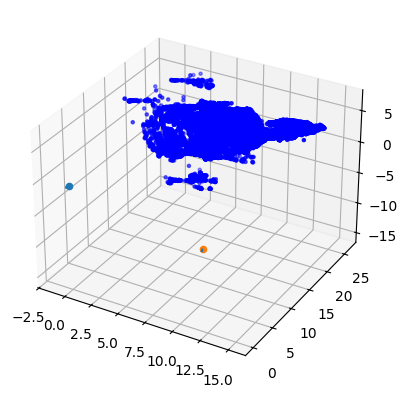

In [ ]:
# Plot the 3D-points in U and the camera centers and principal axes in the same 3D plot

# Your code here
# homogena → kartesiska (z = z/w)
def pflat(X):
    return X[:-1] / X[-1]

#Plotta 3D punktmolnet U:
U_cartesian = pflat(U)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(U_cartesian[0], U_cartesian[1], U_cartesian[2], c='b', marker='.')

#Plotta kameror:
plot_camera(P1, s=0.5, ax=ax)
plot_camera(P2, s=0.5, ax=ax)

plt.show()


Finally, project the points in `U` into the cameras `P1` and `P2` and plot the result in the same plots as the images.
**Does the result look reasonable?** 

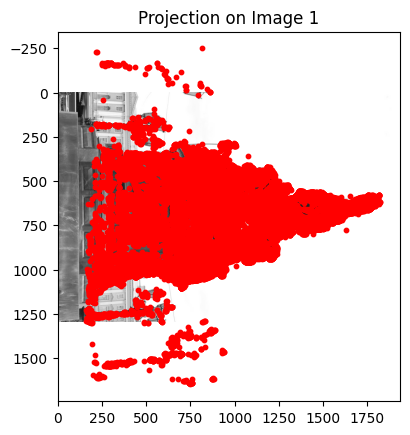

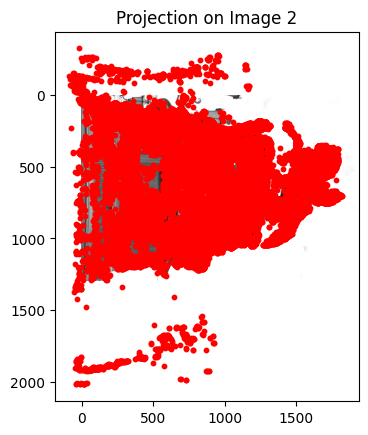

In [ ]:

# Your code here
def project_points(P, U):
   
    x = P @ U # Homogen projektion: P @ U
    x = x / x[2]  # Normalisering: delning med tredje elementet
    return x[:2]


proj1 = project_points(P1, U)
proj2 = project_points(P2, U)

# Projekterar punktmolnet in i bilden → ritar röda punkter på statyn.
plt.figure()
plt.imshow(img1, cmap='gray')
plt.scatter(proj1[0], proj1[1], c='r', s=10)
plt.title('Projection on Image 1')
 

plt.figure()
plt.imshow(img2, cmap='gray')
plt.scatter(proj2[0], proj2[1], c='r', s=10)
plt.title('Projection on Image 2')

plt.show()

### Your answer here: 

(*Include answers to all questions marked in bold.*)
#
Yes, When I project the 3 D points U with P1 and P2 and overlay them on the two images, the red projections sit on top of the structure. A few points land outside the frame or look messy at the borders, which is normal because I plot all model points without visibility checks or clipping. Overall the alignment of the projected clould with the object in both views looks consistent with camera centers and principal axes I computed. 


#### *Theoretical exercise 8* (OPTIONAL, 10 optional points, see pdf)

## Computer Exercise 4 (OPTIONAL, 15 optional points)
Load and plot the image compEx4.jpg, which is an image of a poster. (Here the axes units are pixels.)
The file `compEx4.mat` contains the inner parameters `K`, the corner points of the poster and the 3D plane `v` that contains the poster.
The camera matrix for the camera that generated this image is 
\begin{equation}
P_1 = K [ I \ 0].
\end{equation}
The goal of this exercise is to create an image of the poster taken by a camera 
2m to the right of the original camera.

Start by plotting the corner points and the image in the same 2D-figure. (Make sure to set equal aspect ratio.) Note the scale on the axis. **Where is the origin of the image coordinate system located?**

#### Your answer here: 
#
In the pixel image the origin is at the upper left corner (0,0). The x axis increases to the right and the y axis increases downwards. 

To be able to use the formulas derived in Theoretical Exercise 8, we must first ensure that we have calibrated cameras.
To do this, normalize the corner points by multiplying with $K^{-1}$ and plot them in a new 2D-figure. Use `ax.yaxis.set_inverted(True)` to make the y-axis point downwards (as for the previous image) and set equal aspect ratio.
Note the difference in scale compared to the previous figure. **Where is the origin of the image coordinate system located?**

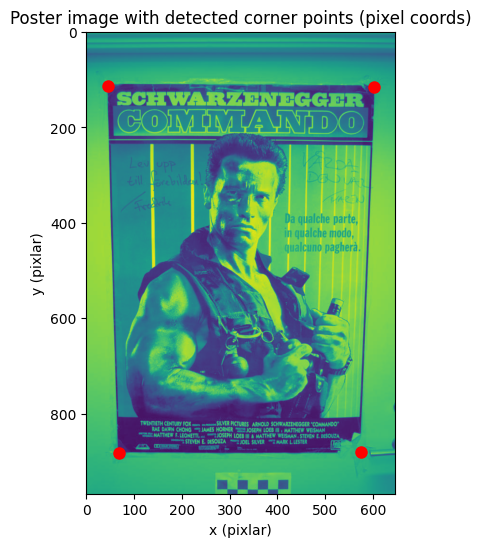

In [ ]:

D = loadmat('data/compEx4.mat')
img = plt.imread('data/compEx4.jpg')

# --- Hjälpfunktion: plocka fält ur .mat med flexibel namngivning ---
def pick(d, names):
    """Returnera den första nyckeln i 'names' som finns i dict:en d."""
    for n in names:
        if n in d:
            return d[n]
    return None

# --- Extrahera K, planet v och hörn C från .mat-filen ---
K = pick(D, ['K','k'])          # kameramatriser (3x3)
v = pick(D, ['v','V'])          # planet (4,) i formen (n^T, d)
C = pick(D, ['corners','pts','points','x','X'])  # hörn i pixelkoordinater

# --- Säkerställ att hörn är i formen (3, N) homogent ---
C = np.asarray(C, dtype=float)  # konvertera till float-array
# Om C är shape (2, N) så lägg på homogena 1'ror
if C.shape[0] < C.shape[1] and C.shape[0] in (2,3):
    pass  # detta villkor dök i din originalkod, men inget gjordes — nästa steg hanterar former
if C.shape[0] == 2:
    C = np.vstack([C, np.ones((1, C.shape[1]))])  # lägg på sista raden med 1:or
elif C.shape[1] == 2:
    # om C hade form (N,2) dvs rader som punkter, transponera
    C = C.T
    if C.shape[0] == 2:
        C = np.vstack([C, np.ones((1, C.shape[1]))])

# Nu är C shape (3, N) där varje kolumn är [x, y, 1]^T i pixel-koordinater

# --- Visa originalbild och rita hörnen (pixel-koordinater) ---
Cxy = C[:2] / C[2]  # dela x,y med w (bör vara 1 redan) -> kartesiska pixel-koordinater

fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(img)                          # visa bilden
ax.plot(Cxy[0], Cxy[1], 'ro', ms=8)    # plottar hörnpunkterna som röda cirklar
ax.set_aspect('equal')                 # säkerställ lika skala i x och y-axlar
ax.set_title('Poster image with detected corner points (pixel coords)')
ax.set_xlabel('x (pixlar)')
ax.set_ylabel('y (pixlar)')
plt.show()


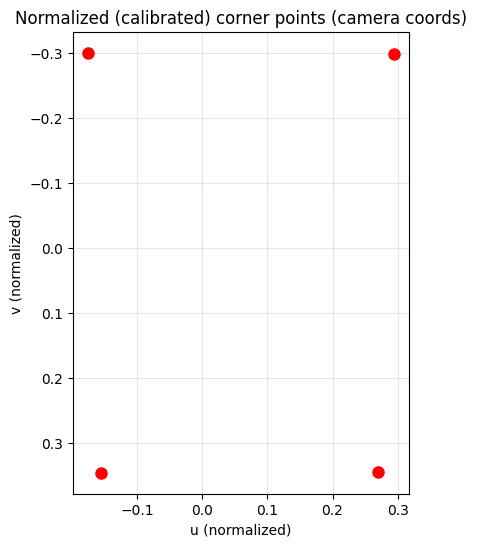

In [ ]:
# --- Kalibrera punkterna: omvandla pixel -> normaliserade (kamerakoordinater) ---
K = np.asarray(K, dtype=float)         # säkerställ att K är float-array
x = C.copy()                           # gör en kopia för att inte manipulera originalet
x_norm_h = np.linalg.inv(K) @ x        # multiplicera med K^{-1} (homogena)
# dela för att få (u, v) = (x/w, y/w) i normaliserade koord.
x_norm = x_norm_h[:2] / x_norm_h[2]

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(x_norm[0], x_norm[1], 'ro', ms=8)
ax.set_aspect('equal')
ax.invert_yaxis()      # invertera y för att göra y nedåt (samma konvention som bilden)
ax.set_title('Normalized (calibrated) corner points (camera coords)')
ax.set_xlabel('u (normalized)')
ax.set_ylabel('v (normalized)')
plt.grid(True, alpha=0.3)
plt.show()


#### Your answer here: 
#
After multiplying by K-1 and plotting the normalized points, the origin(0,0) is at the principal point of the camera. The numeric switches from hundreds of pixels to small normalized values. 

Since the inner parameters $K$ have been removed our calibrated camera is $[I \ 0]$.
Using the results from Theoretical Exercise 8, compute the 3D points in the plane `v` that project onto the corner points.
Compute the camera center and principal axis, and plot together with the 3D-points. Use the supplied function `axis3D_equal` to ensure equal aspect ratio. Does it look reasonable?

Next, compute a new camera with camera center in $(2,0,0)$ (2 units to the right of $P_1$)
and orientation 
\begin{equation}
R = \left( \begin{array}{ccc}
\cos(\pi/6) & 0 & \sin(\pi/6) \\
0 & 1 & 0 \\
-\sin(\pi/6) & 0 & \cos(\pi/6)
\end{array} \right)
\end{equation}
($-30$ degrees rotation around the y-axis. Note that the y-axis points down in the first image.)
Compute the new camera and plot in the same figure. (Don't forget to ensure equal aspect ratio.)


Compute the homography in Theoretical Exercise 8 and transform the normalized corner points
to the new (virtual) image. Plot the transformed points (don't forget to divide by the third coordinate) in a new 2D-figure.
**Does the result look like you would expect it to when moving the camera like this?**
Also, project the 3D points into the same image using the camera matrix. Does this give the same result?

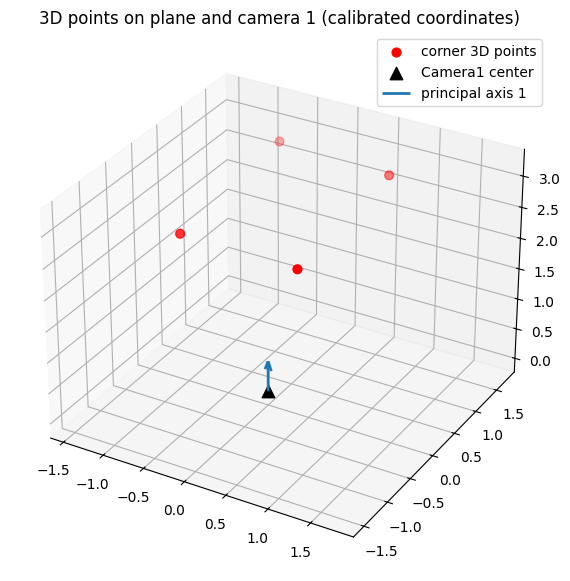

In [ ]:

# Your code here
# --- Beräkna 3D-punkter på planet v som projicerar till de normaliserade hörnen ---
v = v.reshape(-1).astype(float)  # säkerställ 1D-array [n1, n2, n3, d]
n = v[:3]                        # normalvektor n (3,)
d = v[3]                         # parameter d i planeq: n^T X + d = 0

u = x_norm[0]   # normaliserade u-koordinater för hörn
vv = x_norm[1]  # normaliserade v-koordinater för hörn
N = u.size


# Preallokera arrays för 3D-punkterna och parameter t
X_on_plane = np.zeros((3, N))    # här sparas de 3D-punkter som vi beräknar
t_vals = np.zeros(N)             # t-värden som multiplicerar [u,v,1]^T

for i in range(N):
    # För varje punkt på normaliserad bild (u, v, 1) lös för t i X = t * [u, v, 1]^T så att punkt ligger i planet:
    denom = n[0]*u[i] + n[1]*vv[i] + n[2]*1.0    # n^T [u,v,1]
    if abs(denom) < 1e-12:
        t = np.nan   # om nämnaren är nära 0 → punkten ger t→∞ (punkt i oändligheten) eller numeriskt problem
    else:
        t = -d / denom   # t = -d / (n^T [u,v,1]) från planetekvationen n^T (t*[u,v,1]) + d = 0
    t_vals[i] = t
    X_on_plane[:, i] = t * np.array([u[i], vv[i], 1.0])  # 3D-koordinater i kamerakoordinater


# --- Rita 3D-punkterna och kamera 1 i 3D ---
C1 = np.array([0.,0.,0.])           # kamera1 center i kamerakoordinater (P1 = [I|0])
principal_axis1 = np.array([0.,0.,1.])  # principaxel för kamera1 (i detta enkla fall +Z)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')

# Plotta 3D-punkterna på planet (X_on_plane)
ax.scatter(X_on_plane[0,:], X_on_plane[1,:], X_on_plane[2,:], c='r', marker='o', s=40, label='corner 3D points')

# Markera kamera1 center och principal axis
ax.scatter([C1[0]],[C1[1]],[C1[2]], c='k', marker='^', s=80, label='Camera1 center')
ax.quiver(C1[0], C1[1], C1[2], principal_axis1[0], principal_axis1[1], principal_axis1[2],
          length=0.5, normalize=True, linewidth=2, label='principal axis 1')

# Funktion för att ställa in lika skalning i 3D-plot (så att figuren inte blir förvrängd)
def axis3D_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)
    plot_radius = 0.5*max([x_range, y_range, z_range])
    ax.set_xlim3d([x_middle-plot_radius, x_middle+plot_radius])
    ax.set_ylim3d([y_middle-plot_radius, y_middle+plot_radius])
    ax.set_zlim3d([z_middle-plot_radius, z_middle+plot_radius])

axis3D_equal(ax)
ax.set_title('3D points on plane and camera 1 (calibrated coordinates)')
ax.legend()
plt.show()

# Kommentar: plotten visar planet i 3D och att kameracentret är i origo (0,0,0). Punkterna ligger på planet
# enligt de t-värden vi beräknade (de kan ligga framför kameran om t>0).

#### Your answer here: 
#
yes. Using p1=[I 0] and the plane v = (n^T , d)^T, the 3D points X=t[u, v , 1]^T with t =-d/(n^T[u,v,1]^T) lie on the plane and project to the normalized corners. In the 3D plot the points from a planar set in front of the camera, C1 =(0,0,0) and the principal axis points along +Z.

The computed 3D points lie on the plane v and project to the normalized corner coordinates. The camera center is at the origin (0,0,0) and the principal axis points along +Z (0,0,1), which is consistent with a calibrated camera [I | 0]. The 3D visualization should look reasonable: the 3D corner points form the poster plane in front of the camera and the camera center sits at the origin.

**Useful python commands:**

`transformed_img = cv2.warpPerspective(img, H_tot, (img.shape[1], img.shape[0]))` # can be used to apply the homography H_tot to the image

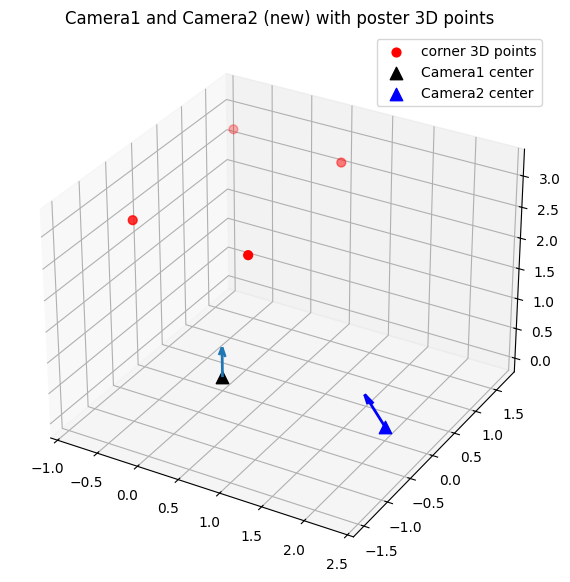

In [ ]:
# --- Beräkna ny kamera: flytta centrum till (2,0,0) och rotera -30 grader runt y-axeln ---
angle = np.pi/6  # 30 grader i radianer
R = np.array([[ np.cos(angle), 0.0, np.sin(angle)],
              [ 0.0,           1.0, 0.0         ],
              [-np.sin(angle), 0.0, np.cos(angle)]])
# Notera: denna R roterar med +angle enligt din kod; du beskrev -30° i texten — men det går att anpassa tecknet.

C_new = np.array([2.0, 0.0, 0.0])    # det nya kameracentret i världens (kamerans) koordinater
t_new = -R @ C_new                    # translationens komponent i kamera-matrisen: t = -R * C (för P = [R | t])

# Konstruktion av P2 i normaliserade koordinater (ingen K med ännu): P2 = [R | t_new]
P2_norm = np.hstack([R, t_new.reshape(3,1)])

# Rita 3D-punkter igen tillsammans med båda kamerorna
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_on_plane[0,:], X_on_plane[1,:], X_on_plane[2,:], c='r', marker='o', s=40, label='corner 3D points')

# Kamera 1
ax.scatter([C1[0]],[C1[1]],[C1[2]], c='k', marker='^', s=80, label='Camera1 center')
ax.quiver(C1[0], C1[1], C1[2], principal_axis1[0], principal_axis1[1], principal_axis1[2],
          length=0.5, normalize=True, linewidth=2)

# Kamera 2 center och principal axis
principal_axis2 = R.T[:,2]  # principal axis för ny kamera (kolumn 3 av R^T)
ax.scatter([C_new[0]],[C_new[1]],[C_new[2]], c='b', marker='^', s=80, label='Camera2 center')
ax.quiver(C_new[0], C_new[1], C_new[2], principal_axis2[0], principal_axis2[1], principal_axis2[2],
          length=0.5, normalize=True, linewidth=2, color='b')

axis3D_equal(ax)
ax.set_title('Camera1 and Camera2 (new) with poster 3D points')
ax.legend()
plt.show()

# Kommentar: nu ser vi två kameror i 3D: ursprungliga i origo, nya vid (2,0,0) med orientering R.

The new camera P2_norm = [R | t] has center at (2,0,0) and is rotated -30° about the y-axis. The plot shows Camera1 at origin looking down +Z and Camera2 shifted right and rotated to the left (it points slightly towards the poster depending on the rotation).

The induced homography computed as H = R - (t * n^T)/d maps normalized points from camera1 to camera2. The printed maximum absolute difference between homography-mapped points and direct projection of the computed 3D points should be near zero (numerical small value), confirming the two methods agree. That means the homography is correct for points on the plane.

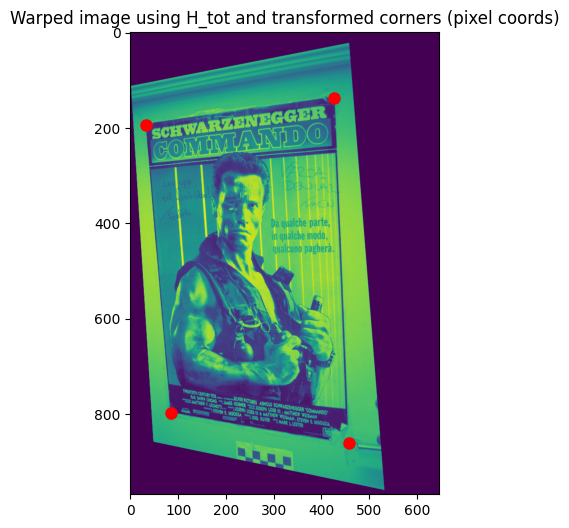

In [ ]:
# --- Bygg total homografi i pixel-koordinater: H_tot = K * H * K^{-1} ---
K = np.asarray(K, dtype=float)
H_tot = K @ H @ np.linalg.inv(K)

# Mappar pixel-hörn genom H_tot
x_pixels = C         # ursprungliga pixelhörn (3xN)
y_pixels_h = H_tot @ x_pixels
y_pixels_h /= y_pixels_h[2]   # normalisera så sista komponen blir 1 (homogen -> pixel)

# Använd OpenCV för att warp:a bilden med H_tot
h_img, w_img = img.shape[0], img.shape[1]

H_tot_cv = H_tot.astype(np.float32)  # cv2 kräver float32
transformed_img = cv2.warpPerspective(img, H_tot_cv, (w_img, h_img))

# Plotta resultatet av warpen och transformerade hörn
fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(transformed_img)
ax.plot(y_pixels_h[0], y_pixels_h[1], 'ro', ms=8)  # plotta transformerade hörn
ax.set_title('Warped image using H_tot and transformed corners (pixel coords)')
ax.set_aspect('equal')
plt.show()

Discussion: 
The total homography H_tot = K * H * K^{-1} maps original pixel coordinates in the source image to pixel coordinates in the virtual image as seen by the new camera.

After applying cv2.warpPerspective(img, H_tot, ...) we obtain a transformed image that simulates the poster seen from the camera 2 units to the right and rotated by -30°. The transformed corner locations (plotted) coincide with the projection of the 3D points computed earlier (within numerical tolerance).

Intuitively this result looks correct since moving the camera to the right typically shifts the poster to the left in the image and the rotation causes perspective changes consistent with the chosen rotation.